**Note:** use T4 GPU runtime on colab

**Hardware Note: Why the NVIDIA T4 GPU?**

DL and quantum simulations rely heavily on parallel matrix operations. 
* **Classical Baseline:** CNNs process thousands of pixel weights via convolution. A CPU processes these sequentially (which is severely bottlenecked). The T4 GPU utilizes thousands of CUDA cores to calculate these matrix multiplications in parallel. This drops epoch times from minutes to ~15 seconds.
* **Quantum Simulation:** Later in this project, we will use PennyLane to simulate quantum circuits. Calculating the tensor products of quantum state vectors scales exponentially. A GPU backend ensures that simulating these quantum states classically does not stall our training pipeline.

#### **Clone git repo and install requirements**

In [1]:
import os

#check if the repository folder already exists on the Colab disk
#(for if we've pushed new changes from remote repo to git and pull them on here)
if os.path.exists('/content/QML4EO-reproduction'):
    print("Repo found! Pulling latest changes from GitHub..")
    %cd /content/QML4EO-reproduction
    !git pull
else:
    print("Cloning repo for the first time..")
    %cd /content
    !git clone https://github.com/yeshapan/QML4EO-reproduction.git
    %cd QML4EO-reproduction

#install required dependencies
!pip install -r requirements.txt -q

Cloning repo for the first time..
/content
Cloning into 'QML4EO-reproduction'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 35 (delta 8), reused 32 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 6.75 MiB | 21.38 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/QML4EO-reproduction
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 123.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### **Test data loader (and confirm satellite images are loading correctly)**

Downloading/Loading EuroSAT dataset into ./data...


100%|██████████| 94.3M/94.3M [00:01<00:00, 50.8MB/s]


Dataset loaded successfully!
Total images: 27000 | Training: 21600 | Validation: 5400
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

Batch Image Tensor Shape: torch.Size([32, 3, 64, 64])
Batch Label Tensor Shape: torch.Size([32])


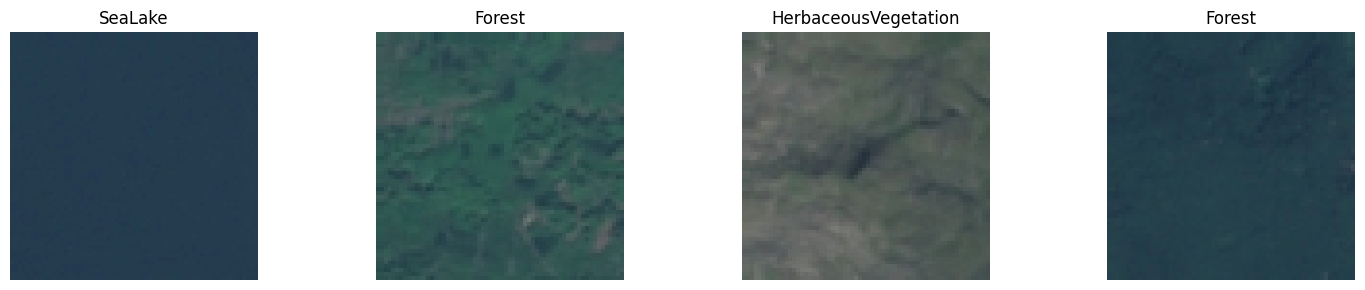

In [2]:
import matplotlib.pyplot as plt
import numpy as np

#import your custom data loader from the src/utils folder
from src.utils.data_loader import get_eurosat_dataloaders

#download and load the data
train_loader, val_loader, classes = get_eurosat_dataloaders(
    data_dir="./data",
    batch_size=32,
    img_size=64
)

#grab exactly one batch of data to inspect it
images, labels = next(iter(train_loader))
print(f"\nBatch Image Tensor Shape: {images.shape}")
print(f"Batch Label Tensor Shape: {labels.shape}")

#let's visualize the first 4 images (to make sure they look right)
fig, axes = plt.subplots(1, 4, figsize=(15, 3))

#we have to reverse the mathematical normalization we did in data_loader.py so matplotlib can display the actual RGB colors correctly
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(4):
    #PyTorch uses (Channels, Height, Width) but Matplotlib needs (Height, Width, Channels)
    img = images[i].numpy().transpose((1, 2, 0))
    img = std * img + mean #un-normalize
    img = np.clip(img, 0, 1) #lock pixel values between 0 and 1

    axes[i].imshow(img)
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

#### **Training the Classical Baseline (CNN)**

Now, we'll establish our classical benchmark. We initialize the lightweight PyTorch CNN (resolution-agnostic via Adaptive Average Pooling) and train it on the EuroSAT dataset.

The goal here is to record the **Total Trainable Parameters**, **Training Time** and **Validation Accuracy** to serve as a direct point of comparison for our hybrid quantum-classical models later.

In [3]:
import torch
from src.utils.data_loader import get_eurosat_dataloaders
from src.baselines.cnn import ClassicalCNN, train_baseline

#verify device and connect to the T4 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware utilized: {device}")

#re-initialize the dataloaders for a clean training run
train_loader, val_loader, classes = get_eurosat_dataloaders(
    data_dir="./data",
    batch_size=32,
    img_size=64
)

#initialize the classical CNN baseline
model = ClassicalCNN(num_classes=len(classes))
model = model.to(device) #push the model to the GPU

#calculate and print total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters (Classical CNN): {total_params:,}")

#execute the training loop!
#we'll run for 5 epochs to establish a solid baseline (without taking too much time)
print("\nStarting Classical Training:")
history = train_baseline(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=5,
    lr=0.001,
    device=device
)

print("\nBaseline training complete!")

Hardware utilized: cuda
Downloading/Loading EuroSAT dataset into ./data...
Dataset loaded successfully!
Total images: 27000 | Training: 21600 | Validation: 5400
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total Trainable Parameters (Classical CNN): 5,418

Starting Classical Training:


Epoch 1/5 [Train]: 100%|██████████| 675/675 [00:17<00:00, 37.85it/s, loss=1.2260]


Epoch 1 Summary -> Train Loss: 1.5139 | Val Accuracy: 56.76%


Epoch 2/5 [Train]: 100%|██████████| 675/675 [00:15<00:00, 42.43it/s, loss=1.0171]


Epoch 2 Summary -> Train Loss: 1.0609 | Val Accuracy: 65.56%


...

Epoch 3 Summary -> Train Loss: 0.9299 | Val Accuracy: 64.76%


Epoch 4/5 [Train]: 100%|██████████| 675/675 [00:15<00:00, 42.95it/s, loss=1.0597]


Epoch 4 Summary -> Train Loss: 0.8395 | Val Accuracy: 67.81%


Epoch 5/5 [Train]: 100%|██████████| 675/675 [00:15<00:00, 42.70it/s, loss=0.5851]


Epoch 5 Summary -> Train Loss: 0.7809 | Val Accuracy: 73.94%

Baseline training complete!
